In [1]:
import numpy as np
import pickle
import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
from interrogator_hardware import InterrogatorHardware
from _utils import find_wlres
from sklearn.model_selection import train_test_split
import keras_tuner as kt
import seaborn as sns
from scipy import stats

2024-02-16 11:04:29.281775: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-16 11:04:29.458605: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Function to build the model based on a set of hyper parameters
def build_model(hp):
    hidden_activation = hp.Choice('hidden_act_1', ['relu', 'tanh', 'sigmoid'])
    hidden_activation_2 = hp.Choice('hidden_act_2', ['relu', 'tanh', 'sigmoid'])
    att_activation = hp.Choice('att_act', ['softmax', 'sigmoid'])
    hidden_size = hp.Int('hidden_size_1', 20, 300, step=10)
    hidden2_size = hp.Int('hidden_size_2', 20, 300, step=10)
    drop_rate = hp.Float('dropout', 0.2, 0.6, step=0.1)
    
    inputs = keras.Input(shape=(13, ), name='input')
    fbg_positions = keras.Input(shape=(13, ), name='fbg_positions')
    
    kernel_l1 = 5e-5
    kernel_l2 = 5e-4
    bias_l2 = 1e-4
    
    concat = keras.layers.Concatenate()([inputs, fbg_positions])
    
    hidden = keras.layers.Dense(hidden_size, activation=hidden_activation,
                                name='hidden')(concat)
    
    hidden = keras.layers.Dropout(drop_rate*0.5)(hidden)
    
    att = keras.layers.Dense(hidden_size, activation=att_activation,
                              name='attention')(concat)
    
    att = keras.layers.Dropout(drop_rate*0.5)(att)
    
    att = keras.layers.multiply([hidden, att], name='mult')
    
    att = keras.layers.Dense(hidden2_size, activation=hidden_activation_2,
                                name='hidden2')(att)
    
    output = keras.layers.Dense(1, activation='linear',
                                bias_constraint=tf.keras.constraints.MinMaxNorm(
                                            min_value=1.5, max_value=1.56, rate=1.0, axis=0),
                                name='output_')(att)
    
    output = keras.layers.Lambda(lambda x: x*1e3, name='output')(output)
    
    model = keras.Model(inputs=[inputs, fbg_positions], outputs=output, name='simple_ann')
    
    def scheduler(epoch, lr):
        if epoch < 10:
            return lr
        else:
            return lr * 0.9
    lr = keras.callbacks.LearningRateScheduler(scheduler)
    
    model.compile(
            loss=keras.losses.MeanSquaredError(),
            optimizer=keras.optimizers.Adam(learning_rate=0.005),
            metrics=[keras.metrics.RootMeanSquaredError(),
                     keras.losses.MeanAbsolutePercentageError()],)

    return model

In [108]:
# Load and preprocess synthetic data
with open('./data/synth.dataset', 'rb') as file:
    synth = pickle.load(file)
    
base_position = np.linspace(1510, 1590, 13)
d_bragg = np.mean(np.diff(base_position))

X = synth['input_strength']
fbg = synth['wl_bragg']
fbg = (fbg - base_position)/d_bragg 
y = synth['target']*1e9

X = X - X.min(axis=1).reshape(-1, 1).repeat(13, axis=1)
X = X / X.sum(axis=1).reshape(-1, 1).repeat(13, axis=1)

In [4]:
# Split synthetic data
index = np.arange(0, len(y))
_, _, train, test = train_test_split(index, index, test_size=0.30, random_state=42)

X_val = X[test, :]
y_val = y[test]
fbg_val = fbg[test, :]

X = X[train, :]
y = y[train]
fbg = fbg[train, :]

In [19]:
# Set the model selection optimizer
tuner = kt.BayesianOptimization(build_model, 
                                objective='val_loss',
                                max_trials=200,
                                num_initial_points=None,
                                alpha=0.0001, beta=2.6, seed=16,
                                directory='tuner',
                                overwrite=False,
                                project_name='ann_2')

es = keras.callbacks.EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=3)
mc = keras.callbacks.ModelCheckpoint( filepath='./checkpoint_2.model.keras', monitor='val_loss', mode='min', save_best_only=True)
tb = keras.callbacks.TensorBoard(log_dir="./tuner/ann_2/tb_logs",
                                histogram_freq=1,
                                 embeddings_freq=1,
                                 write_graph=True,
                                 update_freq='batch')

Reloading Tuner from tuner/ann_2/tuner0.json


In [30]:
# Run model selection
tuner.search(x=[X, fbg], y=y, batch_size=10, epochs=200, 
             validation_data=([X_val, fbg_val], y_val),
             callbacks=[es, mc, tb])

In [33]:
# Get the best model
model = tuner.get_best_models()[0]

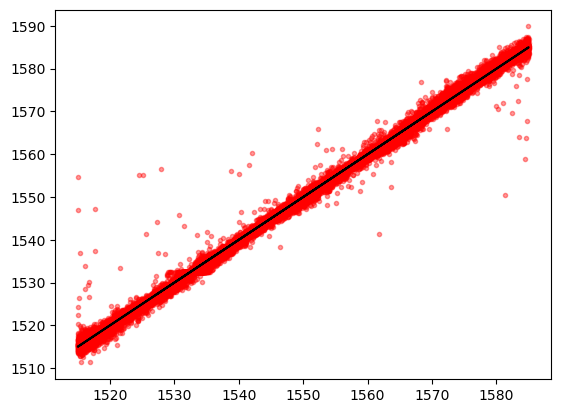

In [35]:
# Show the response for validation data
validated = model.predict([X_val, fbg_val])
plt.plot(y_val, validated, '.r', alpha=0.4)
plt.plot(y_val, y_val, 'k')